# Clasificación y Clustering
## ¿Este mail es spam? Introducción a la clasificación y al clustering
### CLCD 121 · Ciencia de Datos · UGR


Hasta ahora predijimos valores numéricos: cuánto gana un profesional. A eso lo llamamos regresión.

Pero muchos problemas reales no piden un número, sino una decisión:

- ¿Este mail es spam o no?
- ¿Este paciente tiene riesgo alto o bajo?
- ¿Esta transacción es fraudulenta o legítima?

A eso se llama clasificación, y es el tema de la primera parte de esta píldora.

## Parte 1 — Clasificación básica

### ¿Qué es la clasificación?

La clasificación es una tarea del aprendizaje supervisado en la que el modelo aprende
a asignar cada observación a una categoría o clase, a partir de un conjunto de variables
predictoras.

A diferencia de la regresión, donde la salida es un valor numérico continuo, en
clasificación la salida es una etiqueta discreta. Por ejemplo:

- Spam o no spam
- Riesgo alto o riesgo bajo
- Fraude o transacción legítima

Para que el modelo pueda aprender, necesita datos etiquetados: observaciones para
las que ya conocemos la clase correcta. A partir de esos ejemplos, el algoritmo
aprende los patrones que distinguen una clase de la otra y los aplica sobre datos nuevos.

### Elementos clave de un problema de clasificación

- **Clases:** las categorías posibles de salida. En clasificación binaria hay dos
  clases (spam / no spam). En clasificación multiclase puede haber tres o más.
- **Etiqueta (Y):** la clase real de cada observación, que el modelo intenta predecir.
- **Atributos (X):** las variables que el modelo usa para aprender a distinguir las clases.
- **Frontera de decisión:** la línea o superficie que el modelo aprende para separar
  las clases en el espacio de los atributos.
- **Probabilidad de clase:** muchos clasificadores no solo asignan una etiqueta, sino
  que estiman la probabilidad de pertenecer a cada clase. Eso permite ajustar el umbral
  de decisión según el problema.

### El dataset: características de mails

Para trabajar con clasificación necesitamos un dataset etiquetado. En esta píldora
construimos un dataset sintético de 200 mails, donde cada mail está representado
por dos características del texto:

- **palabras_clave:** cantidad de palabras sospechosas que aparecen en el cuerpo
  del mail, como "gratis", "ganaste", "oferta", "hacé clic", entre otras.
- **exclamaciones:** cantidad de signos de exclamación en el asunto del mail.

La etiqueta es binaria: 1 si el mail es spam, 0 si es legítimo (ham).

El dataset está desbalanceado de forma intencional: hay 120 mails ham y 80 spam.
Ese desbalance refleja la realidad, donde la mayoría de los mails recibidos son legítimos.
Este aspecto tiene implicaciones en la evaluación del modelo, que veremos más adelante.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression   # clasificador principal
from sklearn.metrics import (confusion_matrix,        # matriz de confusión
                              classification_report,  # métricas de clasificación
                              accuracy_score)         # exactitud del modelo
from sklearn.cluster import KMeans                    # algoritmo de clustering
from sklearn.preprocessing import StandardScaler      # normalización de variables
from sklearn.model_selection import train_test_split  # división train/test

np.random.seed(42)
sns.set_style('whitegrid')
print('Librerías cargadas ✓')

Librerías cargadas ✓


In [2]:
# ── Dataset: características de mails ────────────────────
# Cada fila es un mail representado por dos características del texto
# Etiqueta: 1 = spam, 0 = no spam (ham)

np.random.seed(42)
n = 200

# Ham (no spam): 120 mails
# Los mails legítimos tienden a tener pocas palabras clave y pocos signos de exclamación
palabras_clave_ham  = np.random.normal(1.5, 0.8, 120).clip(0)
exclamaciones_ham   = np.random.normal(0.5, 0.5, 120).clip(0)
etiqueta_ham        = np.zeros(120)

# Spam: 80 mails
# Los mails spam tienden a tener muchas palabras clave y muchos signos de exclamación
palabras_clave_spam = np.random.normal(4.5, 1.0, 80).clip(0)
exclamaciones_spam  = np.random.normal(3.5, 1.0, 80).clip(0)
etiqueta_spam       = np.ones(80)

# Unimos los dos grupos en un solo dataset
palabras_clave = np.concatenate([palabras_clave_ham, palabras_clave_spam])
exclamaciones  = np.concatenate([exclamaciones_ham,  exclamaciones_spam])
etiqueta       = np.concatenate([etiqueta_ham,        etiqueta_spam])

df = pd.DataFrame({
    'palabras_clave': palabras_clave.round(1),  # cantidad de palabras sospechosas
    'exclamaciones':  exclamaciones.round(1),   # cantidad de signos ! en el asunto
    'spam':           etiqueta.astype(int)       # 1=spam, 0=no spam
})

# Mezclamos los mails aleatoriamente para que no estén ordenados por clase
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print('Dataset de mails:')
print(f'  Total de mails: {len(df)}')
print(f'  No spam (ham):  {(df.spam == 0).sum()}')
print(f'  Spam:           {(df.spam == 1).sum()}')
print()
print(df.head(10).to_string(index=False))

Dataset de mails:
  Total de mails: 200
  No spam (ham):  120
  Spam:           80

 palabras_clave  exclamaciones  spam
            0.3            0.9     0
            1.1            1.3     0
            1.0            0.6     0
            4.6            3.8     1
            6.3            4.1     1
            1.7            0.8     0
            1.0            0.0     0
            4.3            3.5     1
            4.9            5.7     1
            0.9            0.7     0


### Regresión y clasificación: ¿en qué se diferencian?

En regresión la variable de salida es un número continuo. El modelo aprende a estimar
un valor a partir de las variables predictoras, como el salario en las píldoras anteriores.

En clasificación la variable de salida es una categoría. El modelo aprende a asignar
cada observación a una clase a partir de los mismos atributos.

| | Regresión | Clasificación |
|---|---|---|
| Salida | Número continuo | Categoría (clase) |
| Ejemplo | ¿Cuánto gana? | ¿Es spam o no? |
| Algoritmo | Regresión lineal | Regresión logística |
| Métrica principal | R², RMSE | Accuracy, Precision, Recall |

La diferencia no es solo conceptual: cambia el algoritmo que usamos, la forma de
evaluar el modelo y la interpretación de los resultados.

### La regresión logística

La regresión logística es un algoritmo de clasificación. A pesar del nombre, no predice
un número: estima la probabilidad de que una observación pertenezca a una clase.

En nuestro caso, el modelo calcula P(spam) para cada mail. Si esa probabilidad supera
el umbral de 0.5, clasifica el mail como spam. Si no, lo clasifica como ham.

El umbral de 0.5 es el valor por defecto, pero puede ajustarse. Si queremos reducir
el riesgo de enviar mails importantes a la carpeta spam, podemos subir el umbral
a 0.7 u 0.8: el modelo solo va a marcar spam cuando esté muy seguro.

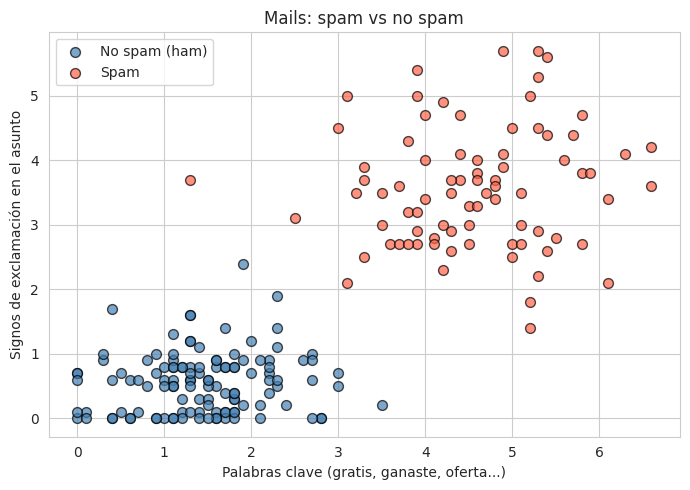

Observación:
  Los puntos rojos (spam) tienden a estar arriba a la derecha.
  Los azules (ham) tienden a estar abajo a la izquierda.
  Hay una separación bastante clara: el modelo debería poder aprender esa frontera.


In [5]:
# ── Visualización: ¿se pueden separar spam y no spam? ────
# Graficamos los mails según sus dos características para ver si hay una separación natural

plt.figure(figsize=(7, 5))
colores   = {0: 'steelblue', 1: 'tomato'}
etiquetas = {0: 'No spam (ham)', 1: 'Spam'}

for clase in [0, 1]:
    mask = df.spam == clase
    plt.scatter(df[mask].palabras_clave, df[mask].exclamaciones,
                c=colores[clase], label=etiquetas[clase],
                alpha=0.7, edgecolors='k', s=50)

plt.xlabel('Palabras clave (gratis, ganaste, oferta...)')
plt.ylabel('Signos de exclamación en el asunto')
plt.title('Mails: spam vs no spam')
plt.legend()
plt.tight_layout()
plt.show()

print('Observación:')
print('  Los puntos rojos (spam) tienden a estar arriba a la derecha.')
print('  Los azules (ham) tienden a estar abajo a la izquierda.')
print('  Hay una separación bastante clara: el modelo debería poder aprender esa frontera.')

### Normalización de variables

Antes de entrenar el modelo es necesario normalizar las variables. La normalización
lleva cada variable a una escala común: media 0 y desvío estándar 1.

¿Por qué es importante? La regresión logística trabaja con distancias y gradientes.
Si una variable tiene valores entre 0 y 10 y otra entre 0 y 1000, la segunda domina
el cálculo y el modelo aprende de forma sesgada. Al normalizar, todas las variables
tienen el mismo peso inicial.

### ¿Qué hace StandardScaler?

StandardScaler transforma cada variable restando su media y dividiéndola por su
desvío estándar:

x_normalizado = (x - media) / desvío_estándar

El resultado es una variable con media 0 y desvío estándar 1, independientemente
de la escala original. Esto no cambia la forma de la distribución ni la relación
entre las observaciones. Solo las pone en una escala comparable.

### División train/test

Al igual que en regresión, dividimos el dataset antes de entrenar:

- 80% de los mails para entrenamiento: el modelo aprende de estos datos.
- 20% de los mails para prueba: se usan solo para evaluar, nunca durante el entrenamiento.

Un detalle clave del proceso de normalización: el scaler aprende la escala a partir
de los datos de entrenamiento (fit_transform). Esa misma escala se aplica luego sobre
los datos de prueba (transform). Nunca se aprende la escala sobre los datos de prueba:
si lo hiciéramos, estaríamos usando información que el modelo no debería conocer
durante la evaluación.

In [6]:
# ── División train/test y entrenamiento ──────────────────

X = df[['palabras_clave', 'exclamaciones']].values
Y = df['spam'].values

# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Normalizamos: StandardScaler lleva cada variable a media 0 y desvío estándar 1
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # aprende la escala en train y transforma
X_test_sc  = scaler.transform(X_test)       # aplica la misma escala en test

# Entrenamos el clasificador
clf = LogisticRegression(random_state=42)
clf.fit(X_train_sc, Y_train)

print('Modelo entrenado ✓')
print(f'  Datos de entrenamiento: {len(X_train)} mails')
print(f'  Datos de prueba:        {len(X_test)} mails')

Modelo entrenado ✓
  Datos de entrenamiento: 160 mails
  Datos de prueba:        40 mails


### La frontera de decisión

La frontera de decisión es la línea — o superficie, en problemas con más de dos
variables — que el modelo aprende para separar las clases en el espacio de los atributos.

Todo lo que queda de un lado de la frontera el modelo lo clasifica como spam.
Todo lo que queda del otro lado lo clasifica como ham.

En la regresión logística con dos atributos, la frontera de decisión es una línea recta.
Con más atributos es un hiperplano — la misma idea que vimos en regresión múltiple,
pero aplicada a separar clases en lugar de ajustar valores.

Los puntos que caen cerca de la frontera son los casos más difíciles: el modelo
tiene poca certeza sobre su clasificación y les asigna probabilidades cercanas a 0.5.
Los puntos que están lejos de la frontera son los casos más claros, con probabilidades
cercanas a 0 o a 1.

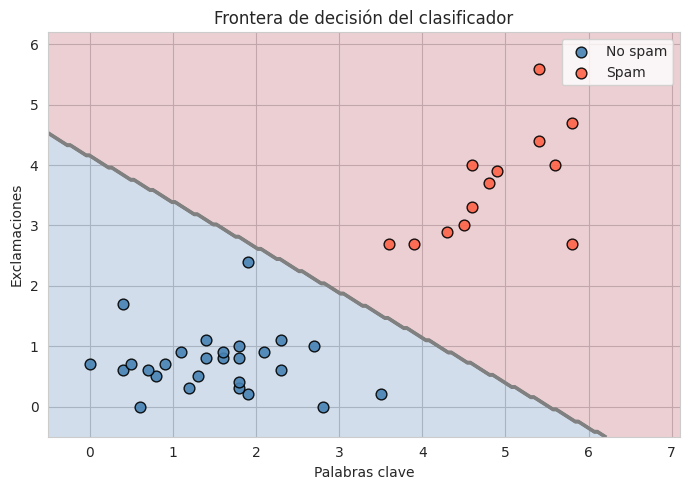

La línea gris es la FRONTERA DE DECISIÓN.
  A la izquierda/abajo → el modelo predice: no spam.
  A la derecha/arriba  → el modelo predice: spam.


In [11]:
# ── Visualización de la frontera de decisión ─────────────
# La frontera separa la zona donde el modelo predice spam de donde predice ham

fig, ax = plt.subplots(figsize=(7, 5))

# Creamos una grilla de puntos para colorear el fondo según la predicción del modelo
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predecimos la clase para cada punto de la grilla
Z = clf.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# Coloreamos el fondo: azul claro = zona ham, rojo claro = zona spam
ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdBu_r')
ax.contour(xx, yy, Z, colors='gray', linewidths=1.5)  # línea de frontera

# Graficamos los datos del conjunto de prueba sobre el fondo
for clase, color, label in [(0, 'steelblue', 'No spam'), (1, 'tomato', 'Spam')]:
    mask = Y_test == clase
    ax.scatter(X_test[mask, 0], X_test[mask, 1],
               c=color, label=label, edgecolors='k', s=60, alpha=0.9)

ax.set_xlabel('Palabras clave')
ax.set_ylabel('Exclamaciones')
ax.set_title('Frontera de decisión del clasificador')
ax.legend()
plt.tight_layout()
plt.show()

print('La línea gris es la FRONTERA DE DECISIÓN.')
print('  A la izquierda/abajo → el modelo predice: no spam.')
print('  A la derecha/arriba  → el modelo predice: spam.')

### Accuracy

La accuracy o exactitud es la métrica más intuitiva para evaluar un clasificador.
Mide el porcentaje de predicciones correctas sobre el total de observaciones:

Accuracy = (TP + TN) / (TP + TN + FP + FN)

Una accuracy de 0.92 significa que el modelo acertó en el 92% de los casos.

Sin embargo, la accuracy tiene una limitación importante en datasets desbalanceados.
Si el 90% de los mails fueran ham, un modelo que clasifique todo como ham sin
aprender nada alcanzaría una accuracy del 90%. Ese número parece bueno pero el
modelo no detectaría ningún spam.

Por eso la accuracy debe interpretarse siempre junto con otras métricas, especialmente
cuando las clases están desbalanceadas.

In [13]:
# ── Evaluación del clasificador ───────────────────────────

Y_pred = clf.predict(X_test_sc)              # predicciones de clase (0 o 1)
Y_prob = clf.predict_proba(X_test_sc)[:, 1]  # probabilidad de ser spam para cada mail

# Exactitud: porcentaje de mails correctamente clasificados
acc = accuracy_score(Y_test, Y_pred)

print('=== EVALUACIÓN DEL CLASIFICADOR ===')
print(f'  Accuracy: {acc:.4f}  →  el {acc*100:.1f}% de los mails fue clasificado correctamente')
print()

# Tabla de ejemplos: características, etiqueta real, predicción y probabilidad
print('=== EJEMPLOS DE PREDICCIÓN ===')
print(f'{"Palabras clave":>15} {"Exclamaciones":>15} {"Real":>8} {"Predicho":>10} {"P(spam)":>10}')
print('-' * 65)
for i in range(8):
    real  = 'SPAM' if Y_test[i] == 1 else 'ham'
    pred  = 'SPAM' if Y_pred[i] == 1 else 'ham'
    prob  = Y_prob[i]
    marca = '✓' if Y_test[i] == Y_pred[i] else '✗'  # ✓ acierto / ✗ error
    print(f'{X_test[i,0]:>15.1f} {X_test[i,1]:>15.1f} {real:>8} {pred:>10} {prob:>9.2f}  {marca}')

=== EVALUACIÓN DEL CLASIFICADOR ===
  Accuracy: 1.0000  →  el 100.0% de los mails fue clasificado correctamente

=== EJEMPLOS DE PREDICCIÓN ===
 Palabras clave   Exclamaciones     Real   Predicho    P(spam)
-----------------------------------------------------------------
            5.8             4.7     SPAM       SPAM      1.00  ✓
            4.8             3.7     SPAM       SPAM      1.00  ✓
            1.9             0.2      ham        ham      0.01  ✓
            1.8             0.3      ham        ham      0.01  ✓
            1.8             0.8      ham        ham      0.03  ✓
            5.4             5.6     SPAM       SPAM      1.00  ✓
            5.8             2.7     SPAM       SPAM      0.99  ✓
            1.8             0.4      ham        ham      0.02  ✓


### La matriz de confusión

La matriz de confusión es una tabla que desglosa los resultados del clasificador
en cuatro categorías, según la combinación entre la clase real y la clase predicha.

| | Predicho: ham | Predicho: spam |
|---|---|---|
| Real: ham | Verdadero Negativo (TN) | Falso Positivo (FP) |
| Real: spam | Falso Negativo (FN) | Verdadero Positivo (TP) |

Cada celda tiene un significado concreto en el problema de spam:

- **Verdadero Negativo (TN):** el modelo identificó correctamente un mail legítimo.
- **Verdadero Positivo (TP):** el modelo detectó correctamente un mail spam.
- **Falso Positivo (FP):** un mail legítimo fue clasificado como spam. Es el error más
  grave: un mail importante puede quedar bloqueado sin que el usuario lo vea.
- **Falso Negativo (FN):** un mail spam llegó al inbox sin ser detectado. Es molesto
  pero generalmente menos grave que el Falso Positivo.

La distinción entre estos dos tipos de error es fundamental. Dos modelos con la
misma accuracy pueden tener distribuciones de errores muy distintas, y dependiendo
del problema uno puede ser mucho más aceptable que el otro.

### Precision, Recall y F1-score

A partir de los valores de la matriz de confusión se calculan tres métricas más
específicas que la accuracy. Cada una responde una pregunta distinta.

**1-Precision**

De todos los mails que el modelo marcó como spam, ¿cuántos eran spam realmente?

Precision = TP / (TP + FP)

Una precision alta significa que cuando el modelo dice spam, casi siempre tiene razón.
Minimiza los Falsos Positivos: mails legítimos enviados a spam por error.

**2-Recall**

De todos los mails que eran spam, ¿cuántos detectó el modelo?

Recall = TP / (TP + FN)

Un recall alto significa que el modelo encuentra la mayoría de los spams.
Minimiza los Falsos Negativos: spams que llegan al inbox sin ser detectados.

**El dilema precision-recall**

Precision y recall tienen una tensión natural: si el modelo es muy conservador
(solo marca algo como spam cuando está casi seguro), tendrá alta precision pero
bajo recall. Si es muy agresivo (marca todo lo que parece sospechoso), tendrá
alto recall pero baja precision.

El umbral de decisión controla ese equilibrio. Un umbral alto (por ejemplo 0.8)
hace al modelo más conservador. Un umbral bajo (por ejemplo 0.3) lo hace más agresivo.

**3-F1-score**

El F1-score combina precision y recall en una sola métrica usando el promedio armónico:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

Un F1 alto indica que el modelo tiene buen desempeño en ambas métricas a la vez.
Es especialmente útil cuando hay desbalance entre clases, porque resume la calidad
del modelo sin dejarse llevar por la clase mayoritaria.

En la Píldora 4 vamos a profundizar en estas métricas y ver cómo elegir la más
adecuada según el problema.

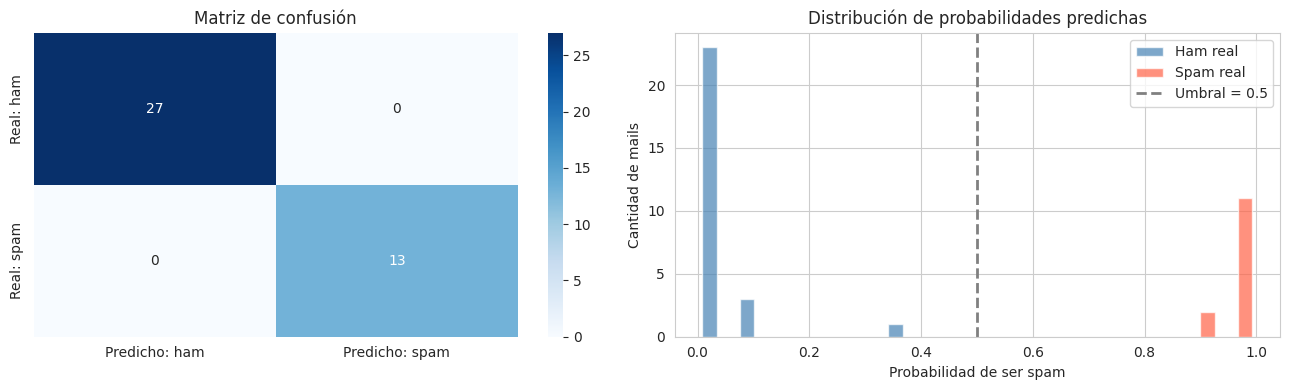

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00        27
        spam       1.00      1.00      1.00        13

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

  Verdaderos Negativos (TN): 27  → hams correctamente identificados
  Falsos Positivos     (FP): 0  → hams enviados a spam por error  ← GRAVE
  Falsos Negativos     (FN): 0  → spams que pasaron al inbox
  Verdaderos Positivos (TP): 13  → spams correctamente bloqueados


In [14]:
# ── Matriz de confusión y distribución de probabilidades ─

cm = confusion_matrix(Y_test, Y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Gráfico 1: Matriz de confusión ---
# Muestra cuántos mails caen en cada combinación real/predicho
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicho: ham', 'Predicho: spam'],
            yticklabels=['Real: ham', 'Real: spam'],
            ax=axes[0])
axes[0].set_title('Matriz de confusión')

# --- Gráfico 2: Distribución de probabilidades predichas ---
# Muestra cómo distribuye el modelo las probabilidades para cada clase real
axes[1].hist([Y_prob[Y_test == 0], Y_prob[Y_test == 1]],
             bins=15, label=['Ham real', 'Spam real'],
             color=['steelblue', 'tomato'], alpha=0.7)
axes[1].axvline(0.5, color='gray', linestyle='--',
                linewidth=2, label='Umbral = 0.5')  # línea de decisión
axes[1].set_xlabel('Probabilidad de ser spam')
axes[1].set_ylabel('Cantidad de mails')
axes[1].set_title('Distribución de probabilidades predichas')
axes[1].legend()

plt.tight_layout()
plt.show()

# Reporte completo con precision, recall y f1-score por clase
print('=== REPORTE DE CLASIFICACIÓN ===')
print(classification_report(Y_test, Y_pred, target_names=['ham', 'spam']))

# Desglose de la matriz en sus cuatro valores
tn, fp, fn, tp = cm.ravel()
print(f'  Verdaderos Negativos (TN): {tn}  → hams correctamente identificados')
print(f'  Falsos Positivos     (FP): {fp}  → hams enviados a spam por error  ← GRAVE')
print(f'  Falsos Negativos     (FN): {fn}  → spams que pasaron al inbox')
print(f'  Verdaderos Positivos (TP): {tp}  → spams correctamente bloqueados')

## Parte 2 — Clustering

### ¿Qué es el clustering?

El clustering es una técnica de aprendizaje no supervisado. A diferencia de la
clasificación, el modelo no cuenta con etiquetas durante el entrenamiento: no sabe
qué mails son spam y cuáles no. Su objetivo es descubrir grupos o estructuras
naturales en los datos, basándose únicamente en la similitud entre las observaciones.

Dos observaciones se consideran similares si sus atributos están cerca en el espacio.
En nuestro caso, si tienen cantidades parecidas de palabras clave y exclamaciones.

El clustering es útil cuando no contamos con datos etiquetados, que es una situación
muy común en la práctica: etiquetar datos requiere tiempo y trabajo humano, mientras
que los datos sin etiquetar suelen estar disponibles en grandes volúmenes.

### K-Means

K-Means es el algoritmo de clustering más básico y uno de los más utilizados.
Agrupa los datos en k clusters de forma que los puntos dentro de cada grupo sean
lo más similares posible entre sí.

El algoritmo funciona en cinco pasos:

1. Se elige k: la cantidad de grupos que se quiere encontrar.
2. Se colocan k centroides en posiciones aleatorias del espacio.
3. Cada observación se asigna al centroide más cercano.
4. Cada centroide se recalcula como el promedio de las observaciones asignadas.
5. Se repiten los pasos 3 y 4 hasta que los centroides no se desplacen.

k es un hiperparámetro: nosotros lo elegimos antes de ejecutar el algoritmo.
En este caso usamos k=2 porque sabemos — desde afuera — que hay dos grupos
naturales en los datos. En la práctica elegir k requiere criterios adicionales
que se profundizarán en la materia correlativa.

Nota: el clustering se introduce aquí a nivel conceptual. Su estudio en profundidad,
incluyendo otros algoritmos y métricas de evaluación, corresponde a la materia correlativa.

In [15]:
# ── K-Means con k=2 ───────────────────────────────────────
# El algoritmo no conoce las etiquetas: solo trabaja con las características

# Normalizamos todo el dataset: K-Means usa distancias,
# todas las variables deben estar en la misma escala
X_sc = scaler.fit_transform(X)

# Ejecutamos K-Means con 2 clusters
kmeans   = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_sc)  # asigna cada mail a un cluster (0 o 1)

df['cluster'] = clusters

print('K-Means ejecutado ✓')
print(f'  Cluster 0: {(clusters == 0).sum()} mails')
print(f'  Cluster 1: {(clusters == 1).sum()} mails')
print()

# Tabla cruzada: muestra cuántos mails de cada clase real cayeron en cada cluster
print('¿Coinciden los clusters con las etiquetas reales?')
print(pd.crosstab(df.spam, df.cluster,
                  rownames=['Etiqueta real'],
                  colnames=['Cluster K-Means']))

K-Means ejecutado ✓
  Cluster 0: 120 mails
  Cluster 1: 80 mails

¿Coinciden los clusters con las etiquetas reales?
Cluster K-Means    0   1
Etiqueta real           
0                120   0
1                  0  80


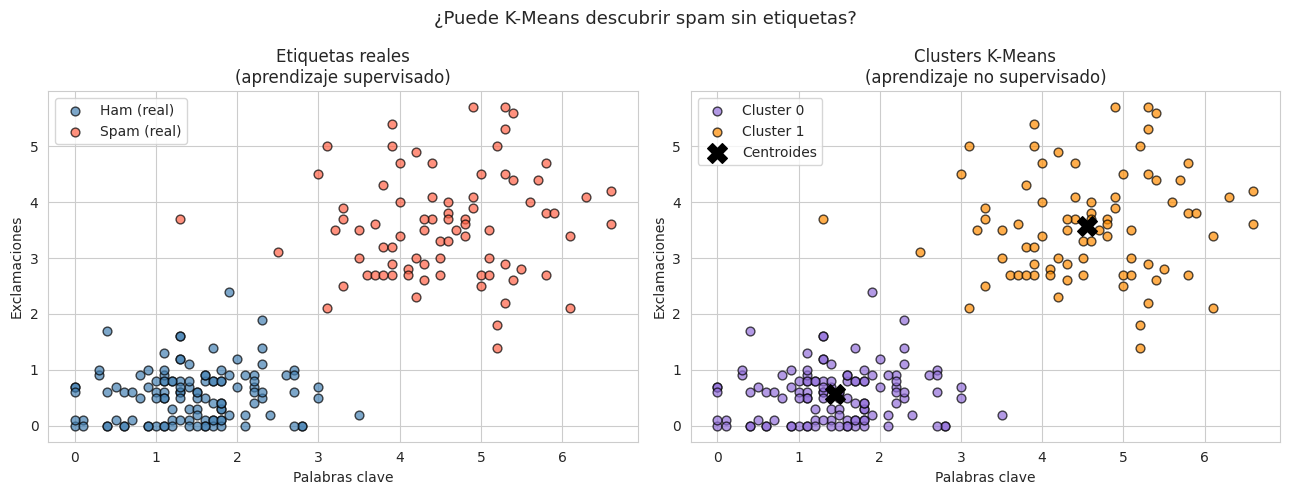

In [16]:
# ── Comparación: etiquetas reales vs clusters descubiertos ─

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Gráfico 1: etiquetas reales (aprendizaje supervisado) ---
for clase, color, label in [(0, 'steelblue', 'Ham (real)'),
                             (1, 'tomato',    'Spam (real)')]:
    mask = df.spam == clase
    axes[0].scatter(df[mask].palabras_clave, df[mask].exclamaciones,
                    c=color, label=label, alpha=0.7, edgecolors='k', s=40)
axes[0].set_title('Etiquetas reales\n(aprendizaje supervisado)')
axes[0].set_xlabel('Palabras clave')
axes[0].set_ylabel('Exclamaciones')
axes[0].legend()

# --- Gráfico 2: clusters encontrados por K-Means (sin etiquetas) ---
for c, color, label in [(0, 'mediumpurple', 'Cluster 0'),
                         (1, 'darkorange',   'Cluster 1')]:
    mask = df.cluster == c
    axes[1].scatter(df[mask].palabras_clave, df[mask].exclamaciones,
                    c=color, label=label, alpha=0.7, edgecolors='k', s=40)

# Graficamos los centroides: representan el mail típico de cada cluster
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
axes[1].scatter(centroides[:, 0], centroides[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroides')
axes[1].set_title('Clusters K-Means\n(aprendizaje no supervisado)')
axes[1].set_xlabel('Palabras clave')
axes[1].set_ylabel('Exclamaciones')
axes[1].legend()

plt.suptitle('¿Puede K-Means descubrir spam sin etiquetas?', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# ── Comparación final: supervisado vs no supervisado ─────

# Accuracy del clasificador supervisado
acc_supervisado = accuracy_score(Y_test, clf.predict(X_test_sc))

# Coincidencia de K-Means con las etiquetas reales
# K-Means puede invertir los números de cluster, tomamos la mejor asignación posible
acc_kmeans_0 = accuracy_score(df.spam, df.cluster)
acc_kmeans_1 = accuracy_score(df.spam, 1 - df.cluster)
acc_kmeans   = max(acc_kmeans_0, acc_kmeans_1)

print('=== SUPERVISADO vs NO SUPERVISADO ===')
print()
print('  Regresión logística (supervisado):')
print('  Conocía las etiquetas durante el entrenamiento.')
print(f'  Accuracy = {acc_supervisado:.4f}  ({acc_supervisado*100:.1f}% de mails bien clasificados)')
print()
print('  K-Means (no supervisado):')
print('  No conocía las etiquetas: descubrió grupos por similitud.')
print(f'  Coincidencia con etiquetas reales = {acc_kmeans:.4f}  ({acc_kmeans*100:.1f}%)')
print()
print('  El clasificador supervisado es más preciso porque aprendió de las etiquetas.')
print('  K-Means descubrió una estructura similar sin conocerlas.')
print('  Eso es útil cuando no contamos con datos etiquetados.')

=== SUPERVISADO vs NO SUPERVISADO ===

  Regresión logística (supervisado):
  Conocía las etiquetas durante el entrenamiento.
  Accuracy = 1.0000  (100.0% de mails bien clasificados)

  K-Means (no supervisado):
  No conocía las etiquetas: descubrió grupos por similitud.
  Coincidencia con etiquetas reales = 1.0000  (100.0%)

  El clasificador supervisado es más preciso porque aprendió de las etiquetas.
  K-Means descubrió una estructura similar sin conocerlas.
  Eso es útil cuando no contamos con datos etiquetados.


## Resumen

| Concepto | Descripción | En nuestro ejemplo |
|----------|-------------|-------------------|
| Clasificación | Predecir una categoría | ¿Spam o no spam? |
| Regresión logística | Clasificador que estima probabilidades | P(spam) para cada mail |
| Frontera de decisión | Línea que separa las clases | Zona spam vs zona ham |
| Accuracy | Porcentaje de predicciones correctas | De 100 mails, ¿cuántos clasifica bien? |
| Matriz de confusión | Detalla los 4 tipos de resultado | TN, FP, FN, TP |
| Falso Positivo | Ham clasificado como spam | Mail importante va a la carpeta spam |
| Precision | TP / (TP + FP) | De los marcados spam, ¿cuántos lo eran? |
| Recall | TP / (TP + FN) | De los spam reales, ¿cuántos detectó? |
| F1-score | Promedio armónico de precision y recall | Balance entre ambas métricas |
| Clustering | Agrupar sin etiquetas | K-Means descubre grupos por similitud |
| K-Means | Algoritmo de clustering básico | Encuentra 2 grupos en los mails |
| Centroide | Centro de cada cluster | Mail típico de cada grupo |


---
Ciencia de Datos · CLCD 121 · Universidad del Gran Rosario